# Parallel BFS with Python Threading

In [1]:
import random
import threading
import time
from collections import deque

class Graph:
    def __init__(self):
        self.adj = {}

    def add_node(self, node):
        if node not in self.adj:
            self.adj[node] = []

    def add_edge(self, u, v, weight=1):
        self.add_node(u)
        self.add_node(v)
        self.adj[u].append(v)
        self.adj[v].append(u)

    def nodes(self):
        return list(self.adj.keys())

    def neighbors(self, u):
        return self.adj.get(u, [])

    def num_nodes(self):
        return len(self.adj)

    def num_edges(self):
        return sum(len(v) for v in self.adj.values()) // 2


def generate_random_graph(n_nodes, avg_degree=6, seed=42):
    rng = random.Random(seed)
    g = Graph()
    node_names = list(range(n_nodes))
    for name in node_names:
        g.add_node(name)
    for u in node_names:
        targets = rng.sample(node_names, min(avg_degree, n_nodes - 1))
        for v in targets:
            if v != u:
                g.add_edge(u, v)
    return g


def sequential_bfs(graph, source):
    visited = {source}
    distances = {source: 0}
    queue = deque([source])
    while queue:
        u = queue.popleft()
        for v in graph.neighbors(u):
            if v not in visited:
                visited.add(v)
                distances[v] = distances[u] + 1
                queue.append(v)
    return visited, distances

## Parallel BFS — Level-Synchronous with Thread Pool per Level

Critical section: the shared `visited` set and `distances` dict are written
by multiple threads concurrently while processing the same BFS level — a
`Lock` protects these from race conditions (two threads discovering the same
node simultaneously could otherwise both add it, corrupting the frontier).

In [2]:
def parallel_bfs(graph, source, num_threads):
    """
    Level-synchronous parallel BFS: within each BFS "level" (distance from
    source), the current frontier's neighbor-exploration work is split
    across num_threads threads. Threads synchronize via a Lock when writing
    to the shared visited set / distances dict / next-frontier list
    (the critical section), and via thread join() as a barrier between levels.
    """
    visited = {source}
    distances = {source: 0}
    lock = threading.Lock()

    current_frontier = [source]
    current_dist = 0

    while current_frontier:
        next_frontier = []

        def worker(chunk):
            local_new = []
            for u in chunk:
                for v in graph.neighbors(u):
                    with lock:  # CRITICAL SECTION
                        if v not in visited:
                            visited.add(v)
                            distances[v] = current_dist + 1
                            local_new.append(v)
            with lock:  # CRITICAL SECTION
                next_frontier.extend(local_new)

        # Split current_frontier into num_threads chunks
        chunk_size = max(1, len(current_frontier) // num_threads)
        chunks = [current_frontier[i:i + chunk_size] for i in range(0, len(current_frontier), chunk_size)]

        threads = [threading.Thread(target=worker, args=(chunk,)) for chunk in chunks]
        for t in threads:
            t.start()
        for t in threads:
            t.join()  # barrier: wait for all threads before moving to next level

        current_frontier = next_frontier
        current_dist += 1

    return visited, distances

## Sanity Test — Correctness Check Against Sequential

In [3]:
g = Graph()
edges = [
    ("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"),
    ("D", "E"), ("E", "F"), ("C", "F"),
]
for u, v in edges:
    g.add_edge(u, v)

seq_visited, seq_distances = sequential_bfs(g, "A")
par_visited, par_distances = parallel_bfs(g, "A", num_threads=2)

print("Sequential distances:", seq_distances)
print("Parallel distances:  ", par_distances)
print("\nMatch:", seq_distances == par_distances)

Sequential distances: {'A': 0, 'B': 1, 'C': 1, 'D': 2, 'F': 2, 'E': 3}
Parallel distances:   {'A': 0, 'B': 1, 'C': 1, 'D': 2, 'F': 2, 'E': 3}

Match: True


## Scalability Test — 1, 2, 4, 8 Threads

In [4]:
big_graph = generate_random_graph(n_nodes=20000, avg_degree=6)

t0 = time.perf_counter()
seq_visited, seq_distances = sequential_bfs(big_graph, 0)
sequential_time = time.perf_counter() - t0
print(f"Sequential: {sequential_time*1000:.2f} ms, nodes visited: {len(seq_visited)}")

thread_counts = [1, 2, 4, 8]
results = []

for n_threads in thread_counts:
    t0 = time.perf_counter()
    par_visited, par_distances = parallel_bfs(big_graph, 0, num_threads=n_threads)
    elapsed = time.perf_counter() - t0

    correct = (par_distances == seq_distances)
    speedup = sequential_time / elapsed

    results.append({
        "threads": n_threads,
        "time_ms": elapsed * 1000,
        "speedup": speedup,
        "correct": correct
    })
    print(f"Threads={n_threads}: time={elapsed*1000:.2f}ms, speedup={speedup:.2f}x, correct={correct}")

Sequential: 5.60 ms, nodes visited: 20000
Threads=1: time=17.57ms, speedup=0.32x, correct=True
Threads=2: time=17.05ms, speedup=0.33x, correct=True
Threads=4: time=17.39ms, speedup=0.32x, correct=True
Threads=8: time=17.82ms, speedup=0.31x, correct=True


## Visualizing Speedup vs Thread Count

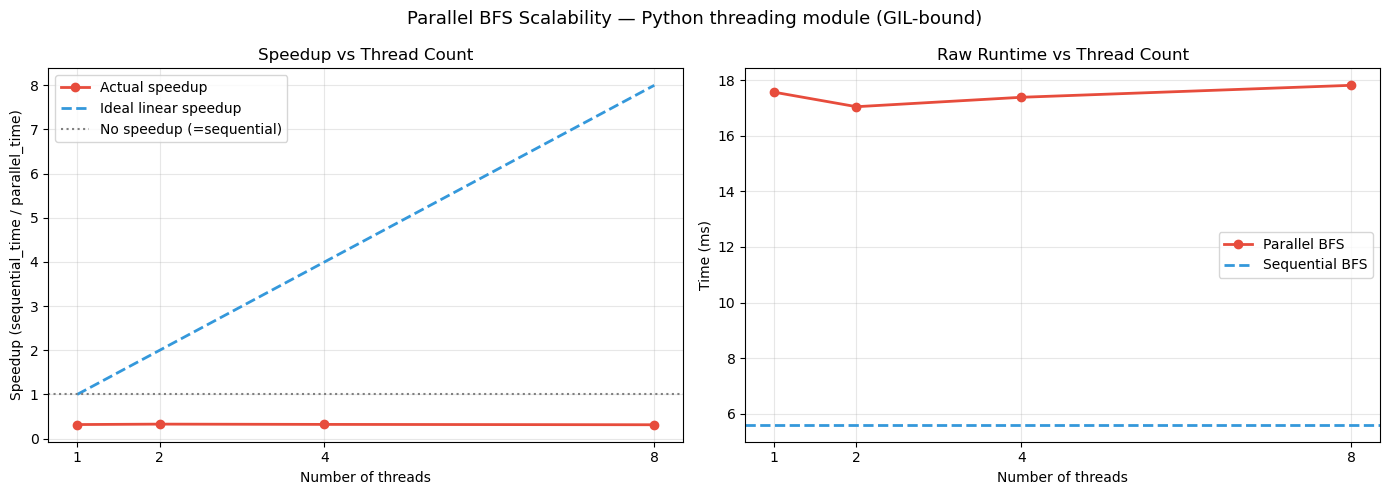

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: actual speedup vs ideal linear speedup
axes[0].plot(df_results["threads"], df_results["speedup"], marker='o', color='#e74c3c', linewidth=2, label='Actual speedup')
axes[0].plot(df_results["threads"], df_results["threads"], '--', color='#3498db', linewidth=2, label='Ideal linear speedup')
axes[0].axhline(y=1.0, color='gray', linestyle=':', label='No speedup (=sequential)')
axes[0].set_xlabel("Number of threads")
axes[0].set_ylabel("Speedup (sequential_time / parallel_time)")
axes[0].set_title("Speedup vs Thread Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(thread_counts)

# Panel 2: raw runtime
axes[1].plot(df_results["threads"], df_results["time_ms"], marker='o', color='#e74c3c', linewidth=2, label='Parallel BFS')
axes[1].axhline(y=sequential_time * 1000, color='#3498db', linestyle='--', linewidth=2, label='Sequential BFS')
axes[1].set_xlabel("Number of threads")
axes[1].set_ylabel("Time (ms)")
axes[1].set_title("Raw Runtime vs Thread Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(thread_counts)

plt.suptitle("Parallel BFS Scalability — Python threading module (GIL-bound)", fontsize=13)
plt.tight_layout()
plt.show()